## Setup

In [24]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance, extract_cnn_feature_maps, pca_on_channels
from src.preprocessing.dataset import ChessSquareDataset, ChessBoardDataset
from src.utils.dataset_utils import get_dataset_stats, build_transforms, get_square_by_class, calculate_stats
from src.utils.plotting import visualize_test_samples, plot_training_history, plot_class_distribution, plot_feature_maps
from src.constants import CLASS_MAP
from tqdm.notebook import tqdm
from collections import Counter
import numpy as np

In [26]:
# Load data

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_SYNTHETIC_DATA_ROOT = os.path.join(project_root, "data/test/synthetic") 
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, NUM_WORKERS)

# Build Final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform)
train_square_dataset = ChessSquareDataset(train_dataset)
test_synthetic_dataset = ChessBoardDataset(root_dir=TEST_SYNTHETIC_DATA_ROOT, transform=train_transform)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform)

test_synthetic_loader = DataLoader(test_synthetic_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1125 | Test samples: 132
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 5/5 [00:16<00:00,  3.26s/it]



Calculated training mean: [0.5405116677284241, 0.5397956371307373, 0.5381444692611694]
Calculated training std:  [0.10387232899665833, 0.10447882860898972, 0.10541636496782303]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 1/1 [00:04<00:00,  4.81s/it]



Calculated test mean: [0.6565031409263611, 0.6223108768463135, 0.5438199639320374]
Calculated test std:  [0.14106103777885437, 0.14781025052070618, 0.13531261682510376]

Pre-loading dataset...


100%|██████████| 1125/1125 [00:36<00:00, 30.45it/s]


In [6]:
# Define baseline model

def get_baseline_model(num_classes=13):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [57]:
import random


def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [ ]:
padding_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1, 1.2, 1.5]

results = {}

print("Starting Padding Experiment...")

for p in padding_values:
    print(f"\n" + "="*40)
    print(f"Testing Padding Factor: {p}")
    print("="*40)
    
    # Initialize datasets with new padding
    train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform, padding=p)
    val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=test_transform, padding=p)
    train_square_dataset = ChessSquareDataset(train_dataset)

    # Calculate weights for weighted loss and sampler
    target_list = train_square_dataset.labels
    class_counts = np.bincount(target_list)
    total_samples = sum(class_counts)
    num_classes = len(class_counts)
    normalized_weights = [total_samples / (num_classes * c) for c in class_counts]
    class_weights = torch.tensor(normalized_weights).float().to(device)
    sampler_weights = 1. / class_counts
    samples_weights = torch.tensor([sampler_weights[t] for t in target_list])

    set_seed()
    
    # Create sampler
    sampler = WeightedRandomSampler(
        weights=samples_weights,
        num_samples=len(samples_weights),
        replacement=True
    )
    
    # Initialize loaders 
    train_loader = DataLoader(train_square_dataset, sampler=sampler, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    
    # Initialize model
    model = get_baseline_model().to(device)

    # Training configuration
    lr = 1e-4
    num_epochs = 12
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Training loop 
    model, history = train(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=None,
        num_epochs=num_epochs,
        device=device,
        save_path=os.path.join(project_root, f'models/baseline_wl_p{p}.pth')
    )

    square_acc, board_acc = evaluate(model, test_real_loader, device)
                
    results[p] = square_acc
    print(f"--> Test Accuracy for padding {p}: {square_acc:.2f}%")

print("\nFinal Padding Experiment Results:", results)

Starting Padding Experiment...

Testing Padding Factor: 0.0
Pre-loading dataset...


100%|██████████| 1125/1125 [00:36<00:00, 30.43it/s]


Training on cuda for 12 epochs...


Training Progress:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/12 | Train: Loss=0.0304 Acc=0.9930  Val: Loss=0.2128 Acc=0.9355   [Saved Best]
Epoch 2/12 | Train: Loss=0.0018 Acc=0.9996  Val: Loss=0.0761 Acc=0.9809   [Saved Best]
Epoch 3/12 | Train: Loss=0.0046 Acc=0.9989  Val: Loss=0.0470 Acc=0.9857   [Saved Best]
Epoch 4/12 | Train: Loss=0.0002 Acc=1.0000  Val: Loss=0.0124 Acc=0.9938   [Saved Best]
Epoch 5/12 | Train: Loss=0.0043 Acc=0.9989  Val: Loss=0.0025 Acc=0.9990   [Saved Best]
Epoch 6/12 | Train: Loss=0.0030 Acc=0.9993  Val: Loss=0.0052 Acc=0.9981  
Epoch 7/12 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0012 Acc=0.9996   [Saved Best]
Epoch 8/12 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0001 Acc=0.9999   [Saved Best]
Epoch 9/12 | Train: Loss=0.0045 Acc=0.9990  Val: Loss=0.0850 Acc=0.9748  
Epoch 10/12 | Train: Loss=0.0015 Acc=0.9996  Val: Loss=0.0024 Acc=0.9995  
Epoch 11/12 | Train: Loss=0.0001 Acc=1.0000  Val: Loss=0.0001 Acc=1.0000   [Saved Best]
Epoch 12/12 | Train: Loss=0.0040 Acc=0.9990  Val: Loss=0.0009 Acc=1.0000  

Trai

...

--> Test Accuracy for padding 1: 59.43%

Testing Padding Factor: 1.2
Pre-loading dataset...


100%|██████████| 1125/1125 [00:55<00:00, 20.35it/s]


Training on cuda for 12 epochs...


Training Progress:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/12 | Train: Loss=0.0740 Acc=0.9805  Val: Loss=0.2524 Acc=0.9274   [Saved Best]
Epoch 2/12 | Train: Loss=0.0069 Acc=0.9983  Val: Loss=0.0922 Acc=0.9761   [Saved Best]


In [55]:
best_model = torch.load(os.path.join(project_root, 'models/baseline_wl_p0.0.pth'))

/tmp/ipykernel_1230603/2454372905.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model = torch.load(os.path.join(project_root, 'models/baseline_wl_p0.0.pth'))


Accuracy per Class:

white_pawn: 1.20% (11/914 correct)
white_rook: 66.98% (144/215 correct)
white_knight: 0.00% (0/142 correct)
white_bishop: 0.00% (0/164 correct)
white_queen: 0.00% (0/95 correct)
white_king: 7.58% (10/132 correct)
black_pawn: 2.53% (23/908 correct)
black_rook: 29.49% (69/234 correct)
black_knight: 0.00% (0/138 correct)
black_bishop: 5.81% (9/155 correct)
black_queen: 10.64% (10/94 correct)
black_king: 0.76% (1/132 correct)
empty     : 99.67% (5108/5125 correct)




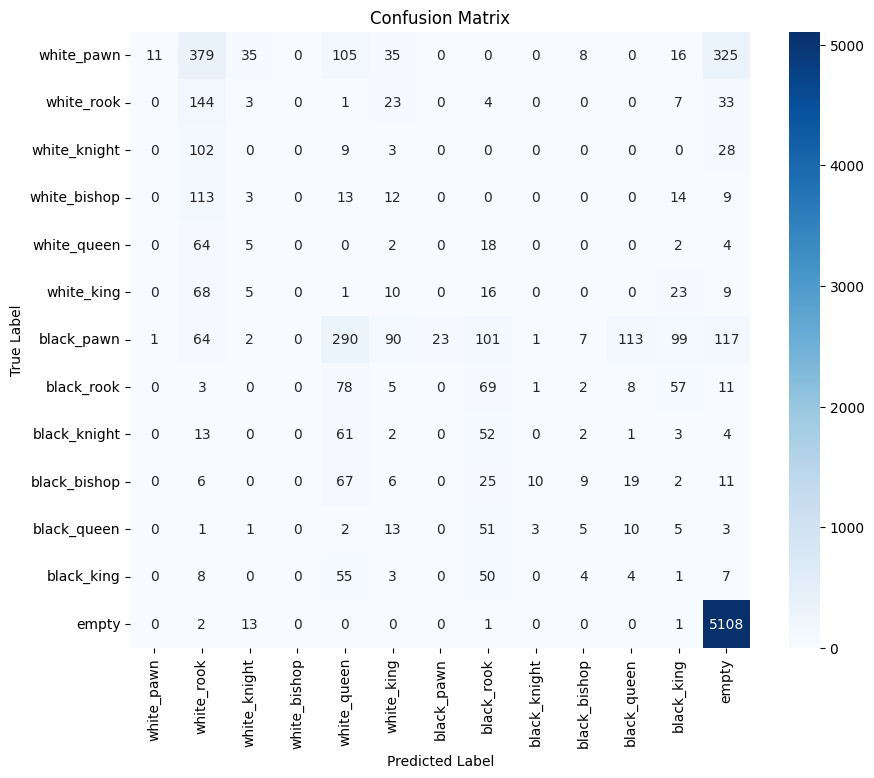

In [56]:
class_names = list(CLASS_MAP.keys())
test_real_dataset.return_fen = False
analyze_model_performance(best_model, test_real_loader, class_names, device)

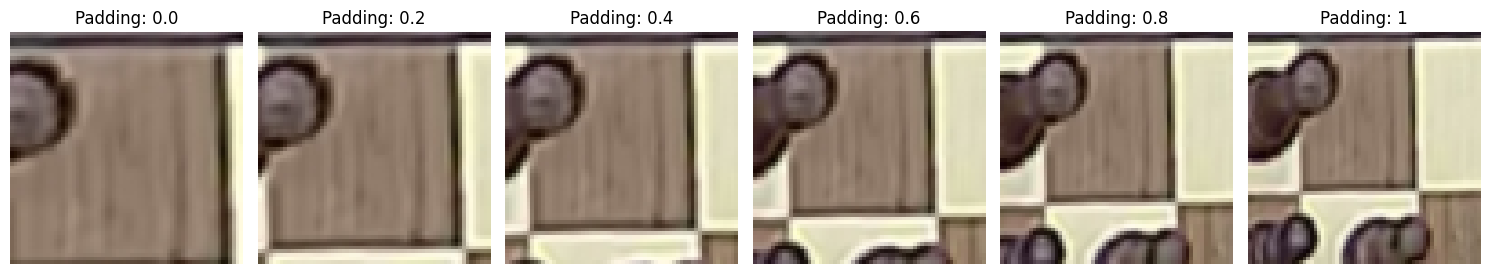

In [59]:
import cv2

viz_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

padding_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1]
    
plt.figure(figsize=(15, 5))

for i, p in enumerate(padding_values):
    ds = ChessBoardDataset(TEST_REAL_DATA_ROOT, transform=viz_transform, padding=p)

    square_idx = 1

    img, label = ds[0]
    img = img[square_idx]
    
    plt.subplot(1, len(padding_values), i+1)
    
    # Convert to numpy for plotting if it's a Tensor
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()
        
    plt.imshow(img)
    plt.title(f"Padding: {p}")
    plt.axis('off')

plt.tight_layout()
plt.show()